In [1]:
pip install networkx matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 14.8 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# Create weighted graph

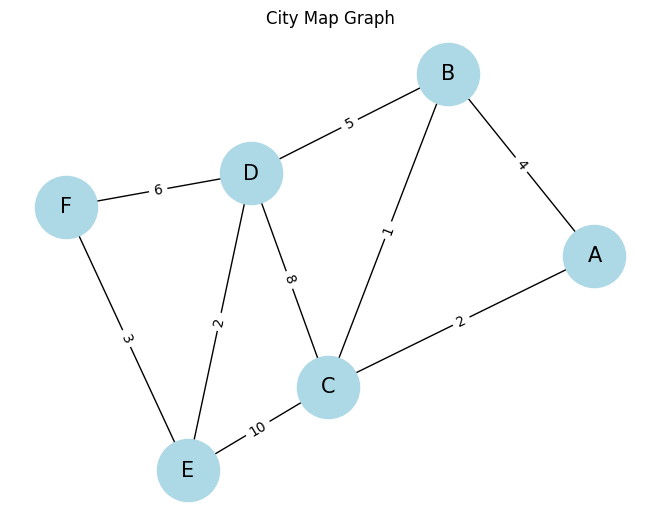

In [3]:
#Create a graph to represent the map
G = nx.Graph()


#Add nodes (cities, locations,etc)
G.add_nodes_from(["A", "B", "C", "D", "E", "F"])


#Add weighted edges (distances between cities)
edges = [
    ("A", "B", 4),
    ("A", "C", 2),
    ("B", "C", 1),
    ("B", "D", 5),
    ("C", "D", 8),
    ("C", "E", 10),
    ("D", "E", 2),
    ("D", "F", 6),
    ("E", "F", 3)
]
G.add_weighted_edges_from(edges)



#Visualize the graph
pos = nx.spring_layout(G, seed=42)  #Layout for consistent visualization
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=15)
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("City Map Graph")
plt.show()

# Find the shortest path using Dijkstra's Algorithm

In [4]:
dijkstra_path = nx.dijkstra_path(G, source="A", target="F", weight="weight")
print("Dijkstra’s shortest path from A to F:", dijkstra_path)

Dijkstra’s shortest path from A to F: ['A', 'C', 'B', 'D', 'E', 'F']


# Find the shortest path using A* Search

In [5]:
#Made-up heuristic: "straight-line distance" (fake values for illustration)
heuristic = {
    "A": 7,
    "B": 6,
    "C": 2,
    "D": 1,
    "E": 1,
    "F": 0
}

#Heuristic function
def heuristic_fn(n1, n2):
    return heuristic[n1]

a_star_path = nx.astar_path(G, source="A", target="F", heuristic=heuristic_fn, weight="weight")
print("A* shortest path from A to F:", a_star_path)

A* shortest path from A to F: ['A', 'C', 'B', 'D', 'E', 'F']


# What if we want a more complex heuristic?

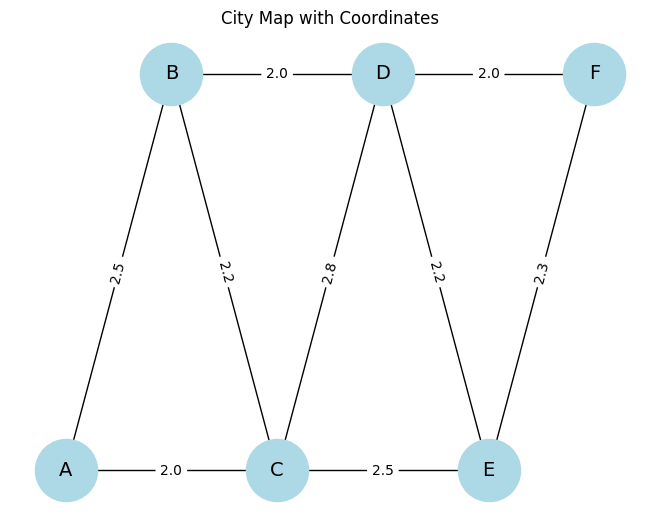

In [6]:
import math

#Create a graph
G = nx.Graph()

#Define nodes and their (x, y) positions on a grid
positions = {
    "A": (0, 0),
    "B": (1, 2),
    "C": (2, 0),
    "D": (3, 2),
    "E": (4, 0),
    "F": (5, 2)
}
G.add_nodes_from(positions.keys())

#Add weighted edges (e.g., road distances in arbitrary units)
edges = [
    ("A", "B", 2.5),
    ("A", "C", 2.0),
    ("B", "C", 2.2),
    ("B", "D", 2.0),
    ("C", "D", 2.8),
    ("C", "E", 2.5),
    ("D", "E", 2.2),
    ("D", "F", 2.0),
    ("E", "F", 2.3)
]
G.add_weighted_edges_from(edges)

#Visualize the graph
nx.draw(G, positions, with_labels=True, node_color='lightblue', node_size=2000, font_size=14)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, positions, edge_labels=edge_labels)
plt.title("City Map with Coordinates")
plt.show()

In [7]:
#Define the coordinate-based heuristic function (Euclidean distance)
def euclidean_heuristic(n1, n2):
    x1, y1 = positions[n1]
    x2, y2 = positions[n2]
    return math.hypot(x2 - x1, y2 - y1)


#Run A* with the Euclidean heuristic
a_star_path = nx.astar_path(G, source="A", target="F", heuristic=euclidean_heuristic, weight="weight")
print("A* shortest path from A to F using Euclidean heuristic:", a_star_path)

A* shortest path from A to F using Euclidean heuristic: ['A', 'B', 'D', 'F']
